In [81]:
!python --version

Python 3.11.14


### Parkinson siblings

#### Study ukb-b-16943

**The Associations Among Gut Microbiota, Branched Chain Amino Acids, and Parkinson’s Disease: Mendelian Randomization Study**

https://doi.org/10.3233/JPD-2402

https://journals.sagepub.com/doi/10.3233/JPD-240244?utm_source=chatgpt.com

- Background:

In experimental and observational studies, the characteristics of gut microbiota have been associated with Parkinson’s disease (PD), among which metabolic pathways played an important role. However, the causality remained unclear.

- Objective:

Herein, we aimed to determine the potential impact of gut microbiota and gut microbiota-derived metabolites on PD risk using a Mendelian randomization (MR) approach.

- Methods:

We included as exposures gut microbial taxa abundance and gut-derived metabolites (branched chain amino acids [BCAAs]), with PD as the outcome. In addition, we explored whether BCAAs act as a mediating factor in the pathway from gut microbiota to PD.

- Results:

We found evidence of a causality of 15 microbial taxa and PD before and after sensitivity analyses, but not after multiple testing correction. There was significant association between BCAAs levels and the risk of PD, especially isoleucine (OR = 0.995, 95% CI 0.992–0.999, p = 0.004, pFDR = 0.012). In addition, the causality of gut microbiota and BCAAs was also explored that the increased g_Coprococcus abundance can result in the decrease in isoleucine level (OR = 1.046; 95% CI, 1.009–1.085; p = 0.016).

The publicly available GWAS summary statistics for PD are also from the IEU Open GWAS database. The GWAS ID is ukb-b-16943, and this dataset contains 361,199 participants with European descent (359,194 controls and 2,005 cases) and 9,851,867 SNPs.

**Important**

Mendelian randomization (MR) provides a genetic epidemiological approach that uses genetic variation as instrumental variable to infer the causality between exposures (some biomarkers) and outcomes (various diseases).19,20 Meanwhile, MR can minimize conventional biases arising from reverse causation and confounding factors. Therefore, based on summarized data from the GWAS, the current study evaluated the genetic validity of gut microbiota and its metabolites in the risk of PD by using a two-sample MR method. Then we investigated whether BCAAs as mediators in the pathway from gut microbiota to PD. Study thought that host genetics can influence the human gut microbiota composition,14 thus it is plausible that risk genotypes for PD act in part through the gut microbiota and its metabolites.

Gut microbiota: The human gut microbiome data (including 207 taxa) from 7738 participants were conducted by the Dutch Microbiome Project and summarized in the published GWAS by Lopera-Maya et al.21 The full GWAS summary statistical data for all 207 taxa can be directly downloaded at NHGRI-EBI GWAS Catalog (https://www.ebi.ac.uk/gwas/) under the study accession numbers GCST90027446-GCST90027857. The GWAS analysis adjusted age, sex, technical covariates, and genetic principal components. The sample of all cohorts came from European descent. As a reference database, SILVA was applied to characterize the gut microbiome profiles of the 16 S ribosomal RNA gene and genotyping data, with truncation of the taxonomic resolution to species level.


19. Lawlor DA, Harbord RM, Sterne JA, et al. Mendelian randomization: using genes as instruments for making causal inferences in epidemiology. Stat Med 2008; 27: 1133–1163.
20. Verduijn M, Siegerink B, Jager KJ, et al. Mendelian randomization: use of genetics to enable causal inference in observational studies. Nephrol Dial Transplant 2010; 25: 1394–1398
21. Lopera-Maya EA, Kurilshikov A, van der Graaf A, et al. Effect of host genetics on the gut microbiome in 7,738 participants of the Dutch Microbiome Project. Nat Genet 2022; 54: 143–151.

#### GWAS Catalog

https://www.ebi.ac.uk/gwas/publications/35115690


#### Participants

- Microbiota analysis -> BCAAs (brench chained AA)
- PD x Health


#### Rout:

- map variants → genes
- build Manhattan plot
- compare multiple UKB GWAS
- integrate with your cancer pipelines (interesting cross-disease angle)


### VCF, GWAS, pysam, VEP

#### samtools - HTSlib, BCFtools

Samtools is a suite of programs for interacting with high-throughput sequencing data. It consists of three separate repositories:

  - Samtools: Reading/writing/editing/indexing/viewing SAM/BAM/CRAM format
  - BCFtools: Reading/writing BCF2/VCF/gVCF files and calling/filtering/summarising SNP and short indel sequence variants
  - HTSlib: A C library for reading/writing high-throughput sequencing data

https://www.htslib.org/


#### VEP (Variant Effect Predictor) ensembl-vep

Ensembl VEP predicts the effect of your variants (SNPs, insertions, deletions, CNVs or structural variants) on gene transcripts and protein sequence, as well as regulatory regions. It reports reference data including gene and variant phenotype associations and population allele frequencies to facilitate variant prioritisation and interpretation.


> VEP (Variant Effect Predictor) predicts the functional effects of genomic variants.  
> Haplosaurus uses phased genotype data to predict whole-transcript haplotype sequences.  
> Variant Recoder translates between different variant encodings.  


https://www.ensembl.org/info/docs/tools/vep/index.html

https://github.com/Ensembl/ensembl-vep


#### pysam

Pysam is a python module that makes it easy to read and manipulate mapped short read sequence data stored in SAM/BAM files. It is a lightweight wrapper of the htslib C-API.

https://pysam.readthedocs.io/en/latest/api.html


In [82]:
from __future__ import annotations

import os, sys
from typing import Dict, Iterable, Optional, Tuple, List
# import math
import pandas as pd
import pysam
import subprocess
import matplotlib.pyplot as plt

from pathlib import Path

ROOT = Path().resolve().parent
SRC = os.path.join(ROOT, "src")

if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

print("ROOT:", ROOT)
print("SRC added:", SRC)

from libs.stat_lib import *
from libs.Basic import *



ROOT: /home/flavio/uv/VCF-GWAS
SRC added: /home/flavio/uv/VCF-GWAS/src


### 🧠 Workflow

harmonized → VEP → gene mapping

### raw x harmonized

- compare raw vs processed (quantitatively)
- detect strand flips / allele issues
- merge multiple UKB GWAS datasets
- build a robust gene-level Parkinson signature

### 👉 Harmonized = all variants are aligned to a consistent reference

That includes:

- same genome build (GRCh37 / GRCh38)
- same DNA strand (forward strand)
- consistent effect allele

In [83]:
root0 = Path("/media/flavio/36873e3e-7941-48d7-aecb-45900ef92659/VCF")
root_vcf = root0 / 'parkinson/ukb-b-16943-siblings'
files = os.listdir(root_vcf)
files

['ukb-b-16943_raw.vcf.gz',
 'ukb-b-16943_VEP.vcf.gz',
 'ukb-b-16943_VEP2.vcf.gz',
 'ukb-b-16943_VEP2.vcf.gz.tbi',
 'ukb-b-16943.vcf.gz',
 'ukb-b-16943_raw.vcf.gz.tbi',
 'README.md',
 'ukb-b-16943.vcf.gz.tbi',
 'ukb-b-16943_VEP.vcf.gz_summary.html']

In [84]:
min_call_rate=0.95
min_maf=0.01
require_pass=False

fname = files[0]
print(">>>", fname)

if fname.endswith('.vcf.gz'):
    print("Ok")
else:
    print("Wrong name, must be a vcf.gz")

filename = str(root_vcf / fname)
filename

>>> ukb-b-16943_raw.vcf.gz
Ok


'/media/flavio/36873e3e-7941-48d7-aecb-45900ef92659/VCF/parkinson/ukb-b-16943-siblings/ukb-b-16943_raw.vcf.gz'

### Convert a VCF/BCF into:

- df         genotype matrix (samples x variants)
- y         phenotype vector (samples)
- df_ctrl    control-only matrix
- df_case    case-only matrix

#### phenotype_map:

- dict like {"sample1": 0, "sample2": 1, ...}
- where 0=normal/control and 1=disease/case

#### Filters:
- keeps only biallelic SNPs
- optional FILTER=PASS
- min call rate
- min minor allele frequency (MAF)

Missing genotypes are imputed with the variant mean dosage.

### SNPs

- SNP stands for single nucleotide polymorphism
- It is the most common type of genetic variation in people
- SNP is whe a single base pair is replaced by another
- For example, the cytosine-guanine ir replaced with a thymine-adenine

![snp](../figures/snp.png)

### ambiguous SNP

- An ambiguous SNP is one where you cannot tell strand orientation.

SNP | Problem  
A/T	looks the same after strand flip  
C/G	looks the same after strand flip  


![dna_flip](../figures/dna_flip.png)


### 🧠 Why ambiguous SNPs are dangerous

They can cause:

- flipped effects
- false associations
- incorrect meta-analysis

### 🔥 How pipelines handle them

#### Option 1 — remove them (most common)

- drop A/T and C/G SNPs

#### Option 2 — keep only if safe

If allele frequency (AF) is available:

- AF ≈ 0.5 → ambiguous → drop
- AF far from 0.5 → can infer strand


#### “Ambiguous SNPs are only ambiguous when sequence context is missing.”





### 🧬 Harmonization

> ✔ consistent allele orientation  
> ✔ same reference genome  
> ✔ comparable across datasets  


#### Ambiguous SNPs

> ❌ A/T or C/G  
> ❌ strand cannot be determined  
> ❌ often removed  


#### 🔥 In UKB files

> ukb-b-16943.vcf.gz → harmonized  
> *_raw.vcf.gz → may contain ambiguous SNPs  


### Available tools:

> detect ambiguous SNPs in your VCF  
> filter them with pysam or bcftools  
> compare raw vs harmonized impact  


### phenotype_map

In [85]:
vcf = pysam.VariantFile(filename)
vcf

### Samples

In [86]:
samples = list(vcf.header.samples)
len(samples), samples

(1, ['UKB-b-16943'])

### Format fields

In [87]:
for k in vcf.header.formats.keys():
    fmt = vcf.header.formats[k]
    print(k, fmt)

AF <pysam.libcbcf.VariantMetadata object at 0x7f0576539090>
ES <pysam.libcbcf.VariantMetadata object at 0x7f057653a830>
SE <pysam.libcbcf.VariantMetadata object at 0x7f057653a4d0>
LP <pysam.libcbcf.VariantMetadata object at 0x7f057653b460>
SS <pysam.libcbcf.VariantMetadata object at 0x7f0576539090>
EZ <pysam.libcbcf.VariantMetadata object at 0x7f057653a830>
SI <pysam.libcbcf.VariantMetadata object at 0x7f057653a4d0>
NC <pysam.libcbcf.VariantMetadata object at 0x7f057653b460>
ID <pysam.libcbcf.VariantMetadata object at 0x7f0576539090>


### scan record and its samples

In [88]:
icount=0

for rec in vcf.fetch():
    icount += 1

    print(f"{icount}) id={rec.id}, chrom={rec.chrom}, pos={rec.pos}, ref={rec.ref}, alts={rec.alts}")

    print("FORMAT fields in this record:", list(rec.format.keys()))

    for sample_name, sample_data in rec.samples.items():
        print(f">>> {sample_name}")

        for key, value in sample_data.items():
            print(f"    {key}: {value}")

    if icount == 5:
        break

1) id=rs10399793, chrom=1, pos=49298, ref=T, alts=('C',)
FORMAT fields in this record: ['ES', 'SE', 'LP', 'AF', 'ID']
>>> UKB-b-16943
    ES: (-0.0005919699906371534,)
    SE: (0.0003105670039076358,)
    LP: (1.24413001537323,)
    AF: (0.6238260269165039,)
    ID: rs10399793
2) id=rs2462492, chrom=1, pos=54676, ref=C, alts=('T',)
FORMAT fields in this record: ['ES', 'SE', 'LP', 'AF', 'ID']
>>> UKB-b-16943
    ES: (-5.32492995262146e-05,)
    SE: (0.00030738298664800823,)
    LP: (0.06550150364637375,)
    AF: (0.4003390073776245,)
    ID: rs2462492
3) id=rs114608975, chrom=1, pos=86028, ref=T, alts=('C',)
FORMAT fields in this record: ['ES', 'SE', 'LP', 'AF', 'ID']
>>> UKB-b-16943
    ES: (0.001133810030296445,)
    SE: (0.0004918259801343083,)
    LP: (1.677780032157898,)
    AF: (0.10352099686861038,)
    ID: rs114608975
4) id=rs6702460, chrom=1, pos=91536, ref=G, alts=('T',)
FORMAT fields in this record: ['ES', 'SE', 'LP', 'AF', 'ID']
>>> UKB-b-16943
    ES: (-0.000136846007080748

### Samples

In [89]:
samples = list(vcf.header.samples)
len(samples), samples

(1, ['UKB-b-16943'])

### Type of VCF

#### If one sees: ['GT', 'DP', 'AD'] --> it is genotype VCF

#### If one sees: ['ES', 'SE', 'LP', 'AF'] --> it is a summary statistics

In [90]:
formats = sorted(list(vcf.header.formats.keys()))

print("FORMAT fields:", formats)

FORMAT fields: ['AF', 'ES', 'EZ', 'ID', 'LP', 'NC', 'SE', 'SI', 'SS']


### VCF diagostic

In [91]:
print("N samples:", len(samples))
print("First samples:", samples[:5])
print("FORMAT fields:", list(vcf.header.formats.keys()))

N samples: 1
First samples: ['UKB-b-16943']
FORMAT fields: ['AF', 'ES', 'SE', 'LP', 'SS', 'EZ', 'SI', 'NC', 'ID']


### 🧬 GWAS summary fields:


| Field | 	Meaning |
|-------|-----------|
| ES | Effect size (β) |
| SE | Standard error |
| LP | −log10(p-value) |
| AF | Allele frequency |
| SS | Sample size |
| EZ | Z-score |
| SI | Study info / internal flag |
| NC | Number of cases (or count-related metric) |
| ID | Variant ID (rsID) |


Obs: rs - reference SNP ID; it is an identifier assigned by the dbSNP database.

### 📦 What information is behind an rsID

Each rsID has:

- chromosome + position
- reference allele / alternative allele
- allele frequencies (across populations)
- links to studies (GWAS, ClinVar, etc.)

### Run VEP on your VCF

```Bash
vep \
  -i UKB-b-16943.vcf.gz \
  -o UKB-b-16943_VEP.vcf.gz \
  --cache \
  --assembly GRCh38 \
  --vcf
  --fork 8
```


### Better command (for GWAS)

```Bash
vep \
  -i UKB-b-16943.vcf.gz \
  -o UKB-b-16943_VEP.vcf.gz \
  --cache \
  --assembly GRCh38 \
  --vcf \
  --symbol \
  --nearest symbol \
  --distance 10000 \
  --everything
  --fork 8
```

In [92]:
fname

'ukb-b-16943_raw.vcf.gz'

### vep command

- But do not combine that with --no-capture-output
- If you want to inspect error text in Python, remove --no-capture-output and add capture_output=True.
- --everything is very broad and can slow runs substantially because it enables many annotations. 
- It is valid, but for a first pass you may prefer a smaller command and add options later. 
- The VEP docs describe --everything as an umbrella convenience option rather than the lightest setup

#### Do not use && in subprocess

- use "--" as argument separator; split flags between tools


In [93]:
files = os.listdir(root_vcf)
# files


fname = files[1]

input_vcf = fname
output_vcf = fname.replace('.vcf.gz', '_VEP.vcf.gz')

input_vcf, output_vcf

('ukb-b-16943_VEP.vcf.gz', 'ukb-b-16943_VEP_VEP.vcf.gz')

In [94]:
vep_cmd = [
    "vep",
    "-i", str(input_vcf),
    "-o", str(output_vcf),
    "--cache",
    "--assembly", "GRCh38",
    "--vcf",
    "--compress_output","bgzip",
    "--symbol",
    "--nearest", "symbol",
    "--distance", "10000",
    "--everything",
    "--fork", "8",
]

vep_cmd_test = [
    "vep",
    "-i", str(input_vcf),
    "-o", str(output_vcf),
    "--cache",
    "--assembly", "GRCh38",
    "--vcf",
    "--compress_output", "bgzip",
    "--symbol",
]

tabix_command = [
    "tabix",
    "-p",
    "vcf",
    str(output_vcf)
]

# env_name = "vep"

conda_cmd = full_cmd = [
    "conda", "run",
    "-n", "vep", "--"
]
# -- argument separator; split flags between tools
#     "--no-capture-output",


In [95]:
root_vcf

PosixPath('/media/flavio/36873e3e-7941-48d7-aecb-45900ef92659/VCF/parkinson/ukb-b-16943-siblings')

In [96]:
full_cmd = conda_cmd + vep_cmd
full_cmd

['conda',
 'run',
 '-n',
 'vep',
 '--',
 'vep',
 '-i',
 'ukb-b-16943_VEP.vcf.gz',
 '-o',
 'ukb-b-16943_VEP_VEP.vcf.gz',
 '--cache',
 '--assembly',
 'GRCh38',
 '--vcf',
 '--compress_output',
 'bgzip',
 '--symbol',
 '--nearest',
 'symbol',
 '--distance',
 '10000',
 '--everything',
 '--fork',
 '8']

### Run

In [97]:
run_vep = False

if run_vep:
    try:
        result = subprocess.run(
            full_cmd,
            cwd=str(root_vcf),
            check=True,
            text=True,
            capture_output=True,
        )
        print("STDOUT:", result.stdout)
        print("STDERR:", result.stderr)
    except subprocess.CalledProcessError as e:
        print(f"Command failed with return code {e.returncode}")
        print("STDOUT:", e.stdout)
        print("STDERR:", e.stderr)
        raise
else:
    print("Don't run")

Don't run


In [98]:
output_vcf = 'ukb-b-16943_VEP.vcf.gz'

### 🔍 Checking ambiguous SNPs in harmonized files

In [99]:
output_vcf2 = 'ukb-b-16943_VEP2.vcf.gz'

filename = str(root_vcf / output_vcf2)

print(">>> vep processed:", filename)

vcf = pysam.VariantFile(filename)

vcf

>>> vep processed: /media/flavio/36873e3e-7941-48d7-aecb-45900ef92659/VCF/parkinson/ukb-b-16943-siblings/ukb-b-16943_VEP2.vcf.gz


### Ambiguous result

> 201,994 / 1,325,664 = 15.24% means about 1 in 6.6 variants in your annotated file are A/T or C/G biallelic SNPs.  

A few important points:

1. This is not surprising.
  - Ambiguous SNPs are common enough that a value around this scale is believable.
2. This does not mean the file is bad.
  - It only means those variants are strand-ambiguous by allele label alone. In a harmonized dataset, many of them may already be safe enough for single-study downstream analysis.
3. Your count is about allele pattern, not error count.
  - You detected:

> A/T  
> T/A  
> C/G  
> G/C  

That is a structural property of the REF/ALT pair. It does not prove those variants are wrong.

In [100]:
def is_ambiguous(ref, alt):
    pair = {ref, alt}
    return pair == {"A", "T"} or pair == {"C", "G"}

amb_count = 0
total = 0

for rec in vcf:
    if rec.alts and len(rec.alts) == 1:
        total += 1
        if is_ambiguous(rec.ref, rec.alts[0]):
            amb_count += 1

print(f"Ambiguous SNPs: {amb_count}/{total} ({amb_count/total:.2%})")

Ambiguous SNPs: 201994/1325664 (15.24%)


#### Extract CSQ fields

- VEP writes gene info in the CSQ field inside INFO.

In [101]:
csq_header = vcf.header.info["CSQ"].description
csq_header

'Consequence annotations from Ensembl VEP. Format: Allele|Consequence|IMPACT|SYMBOL|Gene|Feature_type|Feature|BIOTYPE|EXON|INTRON|HGVSc|HGVSp|cDNA_position|CDS_position|Protein_position|Amino_acids|Codons|Existing_variation|DISTANCE|STRAND|FLAGS|VARIANT_CLASS|SYMBOL_SOURCE|HGNC_ID|CANONICAL|MANE|MANE_SELECT|MANE_PLUS_CLINICAL|TSL|APPRIS|CCDS|ENSP|SWISSPROT|TREMBL|UNIPARC|UNIPROT_ISOFORM|GENE_PHENO|NEAREST|SIFT|PolyPhen|DOMAINS|miRNA|HGVS_OFFSET|AF|AFR_AF|AMR_AF|EAS_AF|EUR_AF|SAS_AF|gnomADe_AF|gnomADe_AFR_AF|gnomADe_AMR_AF|gnomADe_ASJ_AF|gnomADe_EAS_AF|gnomADe_FIN_AF|gnomADe_MID_AF|gnomADe_NFE_AF|gnomADe_REMAINING_AF|gnomADe_SAS_AF|gnomADg_AF|gnomADg_AFR_AF|gnomADg_AMI_AF|gnomADg_AMR_AF|gnomADg_ASJ_AF|gnomADg_EAS_AF|gnomADg_FIN_AF|gnomADg_MID_AF|gnomADg_NFE_AF|gnomADg_REMAINING_AF|gnomADg_SAS_AF|MAX_AF|MAX_AF_POPS|CLIN_SIG|SOMATIC|PHENO|PUBMED|MOTIF_NAME|MOTIF_POS|HIGH_INF_POS|MOTIF_SCORE_CHANGE|TRANSCRIPTION_FACTORS'

In [102]:
csq_fields = csq_header.split("Format: ")[1].split("|")
";".join(csq_fields)

'Allele;Consequence;IMPACT;SYMBOL;Gene;Feature_type;Feature;BIOTYPE;EXON;INTRON;HGVSc;HGVSp;cDNA_position;CDS_position;Protein_position;Amino_acids;Codons;Existing_variation;DISTANCE;STRAND;FLAGS;VARIANT_CLASS;SYMBOL_SOURCE;HGNC_ID;CANONICAL;MANE;MANE_SELECT;MANE_PLUS_CLINICAL;TSL;APPRIS;CCDS;ENSP;SWISSPROT;TREMBL;UNIPARC;UNIPROT_ISOFORM;GENE_PHENO;NEAREST;SIFT;PolyPhen;DOMAINS;miRNA;HGVS_OFFSET;AF;AFR_AF;AMR_AF;EAS_AF;EUR_AF;SAS_AF;gnomADe_AF;gnomADe_AFR_AF;gnomADe_AMR_AF;gnomADe_ASJ_AF;gnomADe_EAS_AF;gnomADe_FIN_AF;gnomADe_MID_AF;gnomADe_NFE_AF;gnomADe_REMAINING_AF;gnomADe_SAS_AF;gnomADg_AF;gnomADg_AFR_AF;gnomADg_AMI_AF;gnomADg_AMR_AF;gnomADg_ASJ_AF;gnomADg_EAS_AF;gnomADg_FIN_AF;gnomADg_MID_AF;gnomADg_NFE_AF;gnomADg_REMAINING_AF;gnomADg_SAS_AF;MAX_AF;MAX_AF_POPS;CLIN_SIG;SOMATIC;PHENO;PUBMED;MOTIF_NAME;MOTIF_POS;HIGH_INF_POS;MOTIF_SCORE_CHANGE;TRANSCRIPTION_FACTORS'

### 🔥 Dealing better with up/down mapped genes (assigned to genes)

You have:

- VEP annotations with --distance 10000
- A gene table (dfgene)
- Evidence that variants are being assigned to genes far away

#### 👉 This is expected behavior, not a bug.

- 🧠 What you should do now (clean solution)
- Instead of changing only --distance, fix it at the annotation level.


#### 👉 Add filters

- keeping only Feature_type == "Transcript"
- excluding weak proximity-only consequences:
  - upstream_gene_variant
  - downstream_gene_variant
  - intergenic_variant

### Remove weak / indirect assignments
```Python
bad = {
    "upstream_gene_variant",
    "downstream_gene_variant",
    "intergenic_variant"
}
```

- If you keep them, you get a broader transcript-level mapping.
- If you remove them, you get a more coding-focused table.


In [103]:
def classify_consequence(consequence: str) -> str:
    terms = set(consequence.split("&"))

    if "intergenic_variant" in terms:
        return "intergenic"
    if "upstream_gene_variant" in terms or "downstream_gene_variant" in terms:
        return "near_gene"
    if "intron_variant" in terms:
        return "intronic"
    if any(x in terms for x in [
        "missense_variant",
        "synonymous_variant",
        "stop_gained",
        "stop_lost",
        "start_lost",
        "splice_donor_variant",
        "splice_acceptor_variant",
        "splice_region_variant",
        "5_prime_UTR_variant",
        "3_prime_UTR_variant"
    ]):
        return "genic"
    return "other"

In [117]:
rows = []

# Remove weak / indirect assignments
bad = {
    "upstream_gene_variant",
    "downstream_gene_variant",
    "intergenic_variant"
}

for rec in vcf.fetch():
    sample = list(rec.samples.values())[0]

    es = sample.get("ES")
    lp = sample.get("LP")
    af = sample.get("AF")

    es = es[0] if isinstance(es, tuple) and len(es) == 1 else es
    lp = lp[0] if isinstance(lp, tuple) and len(lp) == 1 else lp
    af = af[0] if isinstance(af, tuple) and len(af) == 1 else af

    try:
        lp = float(lp)
    except:
        lp = None

    pval = 10**(-lp) if lp is not None else None

    ambiguous = (
        rec.alts is not None and
        len(rec.alts) == 1 and
        is_ambiguous(rec.ref, rec.alts[0])
    )

    csq_list = rec.info.get("CSQ")

    for csq in rec.info.get("CSQ", []):
        data = dict(zip(csq_fields, csq.split("|")))

        # variants → transcript-linked annotations
        # get value → clean it → if empty → treat as missing
        symbol  = (data.get("SYMBOL") or "").strip() or None
        ensembl = (data.get("Gene") or "").strip() or None
        gene = symbol if symbol else ensembl  # keep both separately if possible


        feature_type = data.get("Feature_type")
        consequence = data.get("Consequence", "")
        distance = data.get("DISTANCE")
        nearest = data.get("NEAREST")

        # Keep only transcript-based annotations
        # if feature_type != "Transcript":
        #     continue

        if gene:
            rows.append({
                "chrom": rec.chrom,
                "pos": rec.pos,
                "gene": gene,
                "symbol": symbol,
                "ensembl": ensembl,
                "has_symbol": symbol is not None,
                "has_ensembl": ensembl is not None,
                "variant": rec.id,
                "beta": es,
                "pval": pval,
                "af": af,
                "ambiguous": ambiguous,
                "consequence": consequence,
                "feature_type": feature_type,
                "distance": distance,
                "nearest": nearest,
            })


dfamb = pd.DataFrame(rows)
dfamb["has_gene"] = dfamb["gene"].notna()
dfamb["class"] = dfamb["consequence"].apply(classify_consequence)


print(len(dfamb))
dfamb.head(3)

13784910


,chrom,pos,gene,symbol,ensembl,has_symbol,has_ensembl,variant,beta,pval,af,ambiguous,consequence,feature_type,distance,nearest,has_gene,class
0,1,49298,OR4G4P,OR4G4P,ENSG00000268020,True,True,rs10399793,-0.000592,0.056999,0.623826,False,upstream_gene_variant,Transcript,3175,OR4F5,True,near_gene
1,1,49298,ENSG00000290826,NaN,ENSG00000290826,False,True,rs10399793,-0.000592,0.056999,0.623826,False,upstream_gene_variant,Transcript,8300,OR4F5,True,near_gene
2,1,49298,ENSG00000290826,NaN,ENSG00000290826,False,True,rs10399793,-0.000592,0.056999,0.623826,False,upstream_gene_variant,Transcript,2593,OR4F5,True,near_gene


In [118]:
has_symbols = dfamb["has_symbol"].value_counts().to_list()[0]
has_ensembls = dfamb["has_ensembl"].value_counts().to_list()[0]

f"Have symbols {has_symbols/1000000:.2f} MI ensembls {has_ensembls/1000000:.2f} MI"

'Have symbols 11.60 MI ensembls 13.78 MI'

### New fields,no filter

> you are keeping all CSQ rows that have a gene-like field  
> you are not filtering upstream/downstream/intergenic  
> you also disabled the Feature_type == "Transcript" filter  

So dfamb is now an extended annotation table, not a strict gene-overlap table.

That’s why your first rows are:

> consequence = upstream_gene_variant
> class = near_gene

and the mapped gene is not necessarily the nearest symbol.

#### A subtle point in your example:

gene = OR4G4P or ENSG...
nearest = OR4F5

This means:

> VEP attached the consequence to a specific transcript/gene annotation row  
> the NEAREST field separately reports the nearest gene symbol  
> those do not have to be identical  

In [ ]:
dfamb.head(12)

In [119]:
df2 = dfamb[ (dfamb["feature_type"] != "Transcript") ]
print(len(df2))
df2.head(12)


0


,chrom,pos,gene,symbol,ensembl,has_symbol,has_ensembl,variant,beta,pval,af,ambiguous,consequence,feature_type,distance,nearest,has_gene,class


In [120]:
dfamb_strict = dfamb[
    dfamb['has_symbol'] &
    (dfamb["feature_type"] == "Transcript") &
    ~dfamb["consequence"].apply(
        lambda s: any(term in str(s).split("&") for term in bad)
    )
].copy()

dfamb_strict = dfamb_strict.reset_index(drop=True)
print(len(dfamb_strict))
dfamb_strict.head(12)

8537333


,chrom,pos,gene,symbol,ensembl,has_symbol,has_ensembl,variant,beta,pval,af,ambiguous,consequence,feature_type,distance,nearest,has_gene,class
0,1,706368,LINC00115,LINC00115,ENSG00000225880,True,True,rs12029736,0.000414,0.054,0.515739,False,intron_variant&non_coding_transcript_variant,Transcript,,OR4F16,True,intronic
1,1,706368,LINC00115,LINC00115,ENSG00000225880,True,True,rs12029736,0.000414,0.054,0.515739,False,intron_variant&non_coding_transcript_variant,Transcript,,OR4F16,True,intronic
2,1,706368,LINC00115,LINC00115,ENSG00000225880,True,True,rs12029736,0.000414,0.054,0.515739,False,intron_variant&non_coding_transcript_variant,Transcript,,OR4F16,True,intronic
3,1,706368,LINC00115,LINC00115,ENSG00000225880,True,True,rs12029736,0.000414,0.054,0.515739,False,intron_variant&non_coding_transcript_variant,Transcript,,OR4F16,True,intronic
4,1,706368,LINC00115,LINC00115,ENSG00000225880,True,True,rs12029736,0.000414,0.054,0.515739,False,intron_variant&non_coding_transcript_variant,Transcript,,OR4F16,True,intronic
5,1,706368,LINC00115,LINC00115,ENSG00000225880,True,True,rs12029736,0.000414,0.054,0.515739,False,intron_variant&non_coding_transcript_variant,Transcript,,OR4F16,True,intronic
6,1,706368,LINC00115,LINC00115,ENSG00000225880,True,True,rs12029736,0.000414,0.054,0.515739,False,intron_variant&non_coding_transcript_variant,Transcript,,OR4F16,True,intronic
7,1,763394,LINC00115,LINC00115,ENSG00000225880,True,True,rs3115847,0.000254,0.310,0.706825,False,intron_variant&non_coding_transcript_variant,Transcript,,OR4F16,True,intronic
8,1,763394,LINC00115,LINC00115,ENSG00000225880,True,True,rs3115847,0.000254,0.310,0.706825,False,intron_variant&non_coding_transcript_variant,Transcript,,OR4F16,True,intronic
9,1,763394,LINC00115,LINC00115,ENSG00000225880,True,True,rs3115847,0.000254,0.310,0.706825,False,intron_variant&non_coding_transcript_variant,Transcript,,OR4F16,True,intronic


### Strict Gene Statistics - After (dfstrict_stat)

You now keep only:

- named genes ✔
- transcript-based ✔
- not proximity-only ✔

👉 biologically meaningful gene list

In [123]:
dfamb_strict2 = dfamb_strict.drop_duplicates(
    subset=["chrom", "gene", "variant"]
).copy()

dfstrict_stat = (
    dfamb_strict2.groupby(["chrom", "gene"])
    .agg(
        min_variant_pos=("pos", "min"),
        max_variant_pos=("pos", "max"),
        n_variants=("variant", "nunique"),
        best_pval=("pval", "min"),
        mean_beta=("beta", "mean"),
        median_beta=("beta", "median"),
        mean_af=("af", "mean"),
        n_ambiguous=("ambiguous", "sum"),
    )
    .sort_values("best_pval", ascending=True)
)

print(len(dfstrict_stat))
dfstrict_stat.head(20)

10091


min_variant_pos  max_variant_pos  n_variants  best_pval  \
chrom gene                                                                 
2     SLC25A12         171781498        171999565         255   0.000007   
      PRKCE             45652303         46183424         733   0.000008   
      HAT1             171922537        171985151         103   0.000011   
3     CPNE4            131533805        132280930        1340   0.000022   
2     LINC01143         70889498         70889498           1   0.000028   
4     TMEM175             932974           956047          33   0.000033   
2     METAP1D          172002918        172081096          57   0.000038   
5     GRXCR2           145858530        145936521          77   0.000044   
4     EMCN             100396690        100879212         393   0.000045   
5     PRELID2          145472399        145834529         495   0.000046   
      LINC02242         67632703         67646694          15   0.000048   
      LINC02997         67381221         67806289         477   0.000048   
2     NRXN1             49919228         51225364        1735   0.000052   
      VAX2              70900954         70965196         151   0.000064   
5     BCL9P1            67638051         67638051           1   0.000065   
2     EHBP1             62673967         63046039         328   0.000075   
5     FAM114A2         153990389        154038591          82   0.000079   
2     CERKL            181537380        181675462         129   0.000086   
3     YEATS2           183698219        183812579         170   0.000100   
4     GAK                 849570           931649          87   0.000100   

                 mean_beta  median_beta   mean_af  n_ambiguous  
chrom gene                                                      
2     SLC25A12   -0.000252    -0.000708  0.414833           42  
      PRKCE      -0.000091    -0.000031  0.486746          119  
      HAT1       -0.000483    -0.000712  0.370689           18  
3     CPNE4      -0.000104    -0.000106  0.386216          179  
2     LINC01143  -0.000956    -0.000956  0.179429            0  
4     TMEM175    -0.000435    -0.000532  0.494101            3  
2     METAP1D    -0.000172    -0.000286  0.387450            9  
5     GRXCR2      0.000023     0.000116  0.415698           16  
4     EMCN       -0.000033    -0.000144  0.343844           60  
5     PRELID2     0.000019    -0.000035  0.363217           70  
      LINC02242   0.000472     0.000622  0.262514            5  
      LINC02997   0.000050     0.000060  0.365506           76  
2     NRXN1      -0.000042    -0.000038  0.408929          357  
      VAX2       -0.000328    -0.000225  0.317625           21  
5     BCL9P1      0.000917     0.000917  0.176520            0  
2     EHBP1       0.000039     0.000046  0.485147           46  
5     FAM114A2   -0.000087     0.000033  0.330282            7  
2     CERKL      -0.000033     0.000023  0.460253           26  
3     YEATS2     -0.000122    -0.000062  0.468765           25  
4     GAK        -0.000292    -0.000182  0.479110           13

### All transcripts 🔹 Before (dfamb_stat)

- genes assigned via:
- upstream/downstream
- intergenic proximity
- weak transcript links

👉 inflated gene list

In [122]:
dfamb2 = dfamb.drop_duplicates(subset=["chrom", "gene", "variant"]).copy()

dfamb_stat = (
    dfamb2.groupby(["chrom", "gene"])
    .agg(
        min_variant_pos=("pos", "min"),
        max_variant_pos=("pos", "max"),
        n_variants=("variant", "nunique"),
        best_pval=("pval", "min"),
        mean_beta=("beta", "mean"),
        median_beta=("beta", "median"),
        mean_af=("af", "mean"),
        n_ambiguous=("ambiguous", "sum"),
    )
    .sort_values("best_pval", ascending=True)
)

print(len(dfamb_stat))
dfamb_stat.head(20)

25709


min_variant_pos  max_variant_pos  n_variants  \
chrom gene                                                            
5     ENSG00000248145         13135508         13200500          83   
      ENSG00000296089         13238542         13260304          48   
      RPL12P22               174031302        174050101          17   
      ENSG00000296077         13240427         13262758          49   
      RPS23P5                 13240427         13260439          44   
1     ENSG00000228776         42130865         42146295           4   
      GUCA2B                  42146295         42146295           1   
      ENSG00000307448         42130865         42146295           4   
2     HAT1                   171912911        171995065         129   
      SLC25A12               171771411        172008533         272   
      PRKCE                   45647043         46197117         763   
6     ENSG00000271860         97274244         98466195         992   
      ENSG00000310228         98397820         98500715          96   
3     CPNE4                  131525076        132294075        1349   
6     ENSG00000304821         98491210         98525726          33   
2     ENSG00000296671         70878684         70909100          22   
      LINC01143               70878684         70899002          16   
4     TMEM175                   922349           965779          50   
6     CLNS1AP1                54479262         54494511          21   
4     GAK                       840616           942006         111   

                          best_pval  mean_beta  median_beta   mean_af  \
chrom gene                                                              
5     ENSG00000248145  6.499951e-07  -0.000311    -0.000601  0.339833   
      ENSG00000296089  1.099993e-06  -0.000026    -0.000094  0.430057   
      RPL12P22         2.699975e-06  -0.000033    -0.000145  0.452739   
      ENSG00000296077  3.099989e-06  -0.000066    -0.000123  0.428897   
      RPS23P5          3.099989e-06  -0.000098    -0.000145  0.419834   
1     ENSG00000228776  6.499951e-06  -0.000642    -0.000642  0.451648   
      GUCA2B           6.499951e-06  -0.000855    -0.000855  0.305447   
      ENSG00000307448  6.499951e-06  -0.000642    -0.000642  0.451648   
2     HAT1             7.000030e-06  -0.000424    -0.000710  0.383876   
      SLC25A12         7.000030e-06  -0.000237    -0.000707  0.416706   
      PRKCE            8.000000e-06  -0.000097    -0.000041  0.490888   
6     ENSG00000271860  1.499995e-05   0.000053     0.000049  0.409624   
      ENSG00000310228  1.499995e-05   0.000243     0.000417  0.491098   
3     CPNE4            2.199987e-05  -0.000101    -0.000104  0.385928   
6     ENSG00000304821  2.500001e-05   0.000204     0.000594  0.452661   
2     ENSG00000296671  2.800011e-05  -0.000299    -0.000421  0.391671   
      LINC01143        2.800011e-05  -0.000230    -0.000366  0.395419   
4     TMEM175          3.299969e-05  -0.000377    -0.000421  0.524716   
6     CLNS1AP1         3.599981e-05  -0.000571    -0.000594  0.652495   
4     GAK              3.699986e-05  -0.000309    -0.000205  0.470546   

                       n_ambiguous  
chrom gene                          
5     ENSG00000248145           11  
      ENSG00000296089            8  
      RPL12P22                   3  
      ENSG00000296077            9  
      RPS23P5                    7  
1     ENSG00000228776            0  
      GUCA2B                     0  
      ENSG00000307448            0  
2     HAT1                      25  
      SLC25A12                  46  
      PRKCE                    128  
6     ENSG00000271860          172  
      ENSG00000310228           17  
3     CPNE4                    179  
6     ENSG00000304821            4  
2     ENSG00000296671            5  
      LINC01143                  3  
4     TMEM175                    6  
6     CLNS1AP1                   2  
4     GAK                       17

### Gene-linked table

In [ ]:
dfamb["has_gene"] = dfamb["gene"].notna()

dfclass = dfamb.groupby("class").size()
dfclass

### 📊 Distribution (very informative)


#### Full table

- genic      ~243k
- intronic   ~9.49M
- near_gene  ~3.94M   👈 removed later
- other      ~115k 

#### successfully removed near_gene (strict)

- genic      ~242k   ✔ almost unchanged
- intronic   ~8.22M  ⬇ reduced
- other      ~76k    ⬇ reduced
- near_gene  ❌ gone

In [127]:
dfclass_all = dfamb.groupby(["class", "has_gene"]).size()
dfclass_all

class      has_gene
genic      True         243558
intronic   True        9488157
near_gene  True        3938462
other      True         114733
dtype: int64

In [128]:
dfclass_strict = dfamb_strict.groupby(["class", "has_gene"]).size()
dfclass_strict

class     has_gene
genic     True         242472
intronic  True        8218437
other     True          76424
dtype: int64

### Annotations - each variant can map to many transcript/gene annotations.

- about 13.8 million annotation rows
- not 13.8 million unique variants

Because **each variant can generate multiple CSQ annotations**:

- multiple transcripts
- multiple genes nearby
-  multiple consequences
- repeated Ensembl IDs / transcript-specific entries

That is why the same variant appears more than once.

In [ ]:
print(len(dfamb)/1000000, 'millions')

### 🔬 What you removed


1.09M → 0.725M

👉 ~33% of variants removed

These were mostly:

- intergenic / near-gene variants
- weak transcript assignments
- variants without reliable gene symbol

In [130]:
variants = np.unique(dfamb_strict.variant)
nvar = len(variants)
f"There are {nvar/1000000:.3f} MI variants" 

'There are 0.725 MI variants'

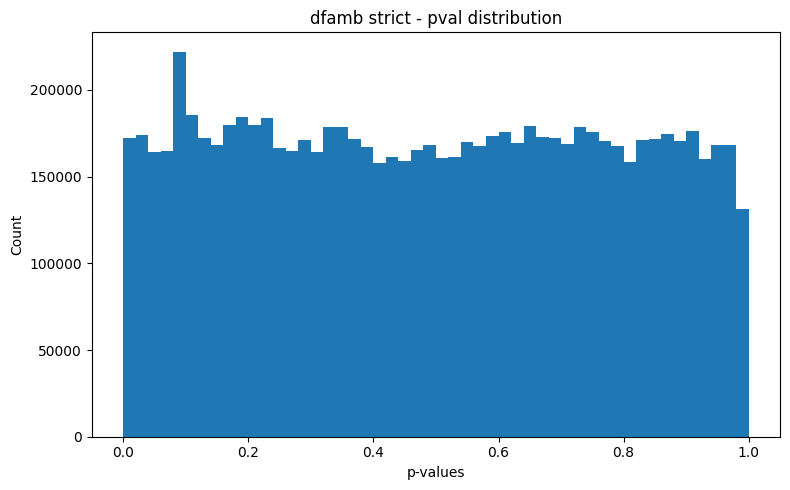

In [131]:
plt.figure(figsize=(8,5))
plt.hist(dfamb_strict["pval"].dropna(), bins=50)
plt.xlabel("p-values")
plt.ylabel("Count")
plt.title("dfamb strict - pval distribution")
plt.tight_layout()
plt.show()

### Summary 🧠 Interpretation

✔ Ambiguous SNPs behave like background noise


They are:

- not enriched in significant hits
- not concentrated in key genes
- not driving your results
- ✔ Your strict gene mapping is robust

Even after:

- removing near-gene variants
- keeping only transcript-linked
- keeping only SYMBOL genes

👉 results are stable

🔥 Strong conclusion

Ambiguous SNP filtering is optional for your analysis

In [133]:
df_noamb = dfamb_strict[~dfamb_strict["ambiguous"]].copy()

pval_threshold = 0.005

df_summ = pd.DataFrame({
    "all_strict": {
        "n_rows": len(dfamb_strict),
        "n_variants": dfamb_strict["variant"].nunique(),
        "n_genes": dfamb_strict["gene"].nunique(),
        "n_sig_rows": (dfamb_strict["pval"] < pval_threshold).sum(),
        "n_ambiguous_rows": dfamb_strict["ambiguous"].sum(),
    },
    "no_ambiguous": {
        "n_rows": len(df_noamb),
        "n_variants": df_noamb["variant"].nunique(),
        "n_genes": df_noamb["gene"].nunique(),
        "n_sig_rows": (df_noamb["pval"] < pval_threshold).sum(),
        "n_ambiguous_rows": df_noamb["ambiguous"].sum(),
    }
}).T

df_summ

,n_rows,n_variants,n_genes,n_sig_rows,n_ambiguous_rows
all_strict,8537333,724870,10079,45067,1278912
no_ambiguous,7258421,615338,9871,38767,0


### 🧬 What is beta (ES)?

In your file, ES = beta = effect size

👉 It tells you: how much the allele changes the trait


#### 🔬 In a case-control GWAS (like yours)

Beta usually comes from logistic regression:

> positive beta → increases disease risk  
> negative beta → decreases disease risk  

| Beta | Meaning |
|-----|----------|
| +	|  risk-increasing |
| −	| protective |

### 🚀 Next steps

- quantify how many SNPs were removed by harmonization
- compare gene hits raw vs clean
- detect strand issues automatically

In [134]:
import pandas as pd

rows = []

for rec in vcf.fetch():
    for sample_name, sample_data in rec.samples.items():
        es = sample_data.get("ES")
        se = sample_data.get("SE")
        lp = sample_data.get("LP")
        af = sample_data.get("AF")
        var_id = sample_data.get("ID")

        es = es[0] if isinstance(es, tuple) and len(es) == 1 else es
        se = se[0] if isinstance(se, tuple) and len(se) == 1 else se
        lp = lp[0] if isinstance(lp, tuple) and len(lp) == 1 else lp
        af = af[0] if isinstance(af, tuple) and len(af) == 1 else af

        pval = 10 ** (-lp) if lp is not None else None

        rows.append({
            "sample": sample_name,
            "chrom": rec.chrom,
            "pos": rec.pos,
            "ref": rec.ref,
            "alt": rec.alts[0] if rec.alts else None,
            "record_id": rec.id,
            "variant_id": var_id,
            "ES": es,
            "SE": se,
            "LP": lp,
            "pval": pval,
            "AF": af,
        })

dfvar = pd.DataFrame(rows)
dfvar['fdr'] = fdr(dfvar.pval)

print(len(dfvar))

dfvar.head(3)

1325664


,sample,chrom,pos,ref,alt,record_id,variant_id,ES,SE,LP,pval,AF,fdr
0,UKB-b-16943,1,49298,T,C,rs10399793,rs10399793,-0.000592,0.000311,1.244130,0.056999,0.623826,0.906356
1,UKB-b-16943,1,54676,C,T,rs2462492,rs2462492,-0.000053,0.000307,0.065502,0.860000,0.400339,0.995508
2,UKB-b-16943,1,91536,G,T,rs6702460,rs6702460,-0.000137,0.000303,0.187087,0.649999,0.456755,0.987931


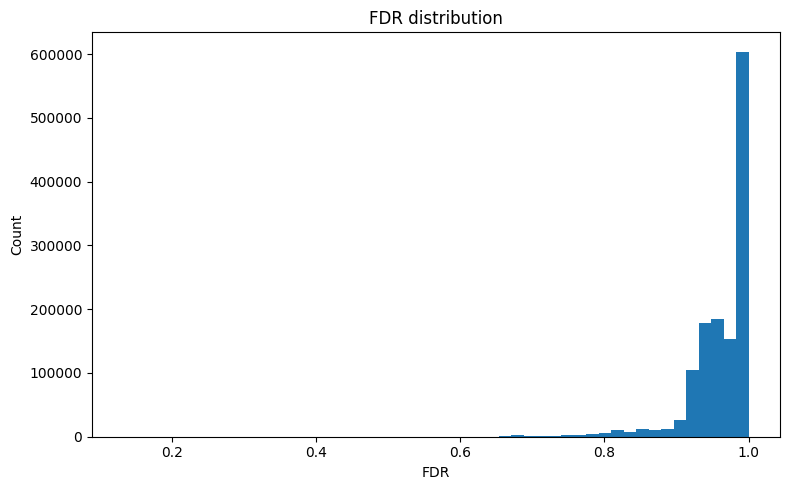

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dfvar["fdr"].dropna(), bins=50)
plt.xlabel("FDR")
plt.ylabel("Count")
plt.title("FDR distribution")
plt.tight_layout()
plt.show()

In [136]:
dfcool = dfvar[dfvar.fdr < 0.25]
print(len(dfcool))

dfcool

13


,sample,chrom,pos,ref,alt,record_id,variant_id,ES,SE,LP,pval,AF,fdr
995903,UKB-b-16943,5,13169579,G,A,rs26230,rs26230,0.000864,0.000177,5.95861,1.099993e-06,0.493078,0.132566
995922,UKB-b-16943,5,13189393,A,G,rs26227,rs26227,0.000891,0.000181,6.09152,8.099910e-07,0.398570,0.214755
995926,UKB-b-16943,5,13190750,C,T,rs28202,rs28202,0.000837,0.000177,5.65758,2.199987e-06,0.485024,0.201134
995935,UKB-b-16943,5,13197901,G,A,rs32541,rs32541,0.000891,0.000181,6.07572,8.400017e-07,0.395711,0.185593
995942,UKB-b-16943,5,13201033,C,T,rs32544,rs32544,0.000887,0.000181,6.04096,9.099974e-07,0.395881,0.172336
995949,UKB-b-16943,5,13205087,C,T,rs32546,rs32546,0.000885,0.000180,6.03152,9.299939e-07,0.400920,0.154107
995959,UKB-b-16943,5,13214852,C,T,rs28207,rs28207,0.000885,0.000180,6.02687,9.400051e-07,0.396775,0.138459
995960,UKB-b-16943,5,13214859,T,C,rs28283,rs28283,0.000851,0.000176,5.85387,1.400007e-06,0.484765,0.142764
995961,UKB-b-16943,5,13215083,T,C,rs32520,rs32520,0.000835,0.000176,5.65758,2.199987e-06,0.491316,0.201134
995995,UKB-b-16943,5,13237036,C,T,rs11744248,rs11744248,0.000877,0.000180,5.95861,1.099993e-06,0.395299,0.132566


In [ ]:
def plot_manhattan(df, chrom_col="chrom", pos_col="pos", p_col="pval", figsize=(14, 6)):
    d = df[[chrom_col, pos_col, p_col]].copy()
    d = d.dropna()
    d = d[d[p_col] > 0].copy()

    # keep autosomes/X/Y if needed; here just sort naturally if possible
    def chrom_key(x):
        x = str(x).replace("chr", "")
        if x == "X":
            return 23
        if x == "Y":
            return 24
        try:
            return int(x)
        except ValueError:
            return 10**9

    d["chrom_sort"] = d[chrom_col].map(chrom_key)
    d = d.sort_values(["chrom_sort", pos_col]).copy()

    d["mlog10p"] = -np.log10(d[p_col])

    # cumulative genomic position
    xvals = []
    xticks = []
    xlabels = []
    offset = 0

    for chrom, sub in d.groupby(chrom_col, sort=False):
        sub = sub.sort_values(pos_col)
        x = sub[pos_col].values + offset
        xvals.extend(x)

        xticks.append(x.mean())
        xlabels.append(str(chrom))

        offset = x.max()

    d["x"] = xvals

    plt.figure(figsize=figsize)

    for i, (chrom, sub) in enumerate(d.groupby(chrom_col, sort=False)):
        plt.scatter(
            sub["x"],
            sub["mlog10p"],
            s=8,0.
            alpha=0.7,
            label=str(chrom) if i < 5 else None
        )

    # genome-wide significance line
    plt.axhline(-np.log10(5e-8), linestyle="--", linewidth=1)

    plt.xticks(xticks, xlabels, rotation=0)
    plt.xlabel("Chromosome")
    plt.ylabel("-log10(p-value)")
    plt.title("Manhattan plot")
    plt.tight_layout()
    plt.show()

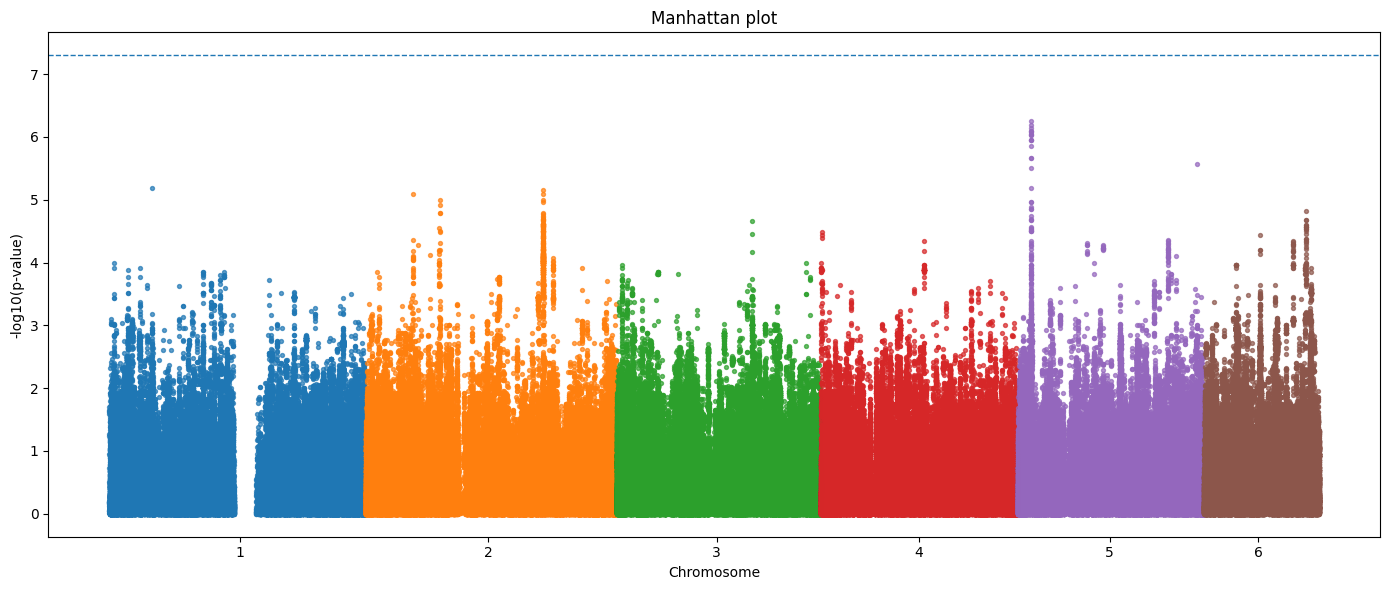

In [138]:
plot_manhattan(dfvar, chrom_col="chrom", pos_col="pos", p_col="pval", figsize=(14, 6))

In [ ]:
sorted(dfvar["chrom"].unique())

In [ ]:
def plot_manhattan_highlight(df, chrom_col="chrom", pos_col="pos", p_col="pval", fdr_col="fdr", fdr_thr=0.25, figsize=(14,6)):
    d = df[[chrom_col, pos_col, p_col, fdr_col]].copy()
    d = d.dropna()
    d = d[d[p_col] > 0].copy()

    def chrom_key(x):
        x = str(x).replace("chr", "")
        if x == "X":
            return 23
        if x == "Y":
            return 24
        try:
            return int(x)
        except ValueError:
            return 10**9

    d["chrom_sort"] = d[chrom_col].map(chrom_key)
    d = d.sort_values(["chrom_sort", pos_col]).copy()
    d["mlog10p"] = -np.log10(d[p_col])

    xvals = []
    xticks = []
    xlabels = []
    offset = 0

    for chrom, sub in d.groupby(chrom_col, sort=False):
        sub = sub.sort_values(pos_col)
        x = sub[pos_col].values + offset
        xvals.extend(x)
        xticks.append(x.mean())
        xlabels.append(str(chrom))
        offset = x.max()

    d["x"] = xvals

    base = d[d[fdr_col] >= fdr_thr]
    hit = d[d[fdr_col] < fdr_thr]

    plt.figure(figsize=figsize)
    plt.scatter(base["x"], base["mlog10p"], s=8, alpha=0.5)
    plt.scatter(hit["x"], hit["mlog10p"], s=10, alpha=0.9)

    plt.axhline(-np.log10(5e-8), linestyle="--", linewidth=1)
    plt.xticks(xticks, xlabels)
    plt.xlabel("Chromosome")
    plt.ylabel("-log10(p-value)")
    plt.title(f"Manhattan plot (highlight FDR < {fdr_thr})")
    plt.tight_layout()
    plt.show()

In [ ]:
plot_manhattan_highlight(dfvar, fdr_thr=0.25)

### 🔬 Results: Top hits:

All strongest variants are in:

> chr5 : ~13.1 – 13.3 Mb  
> locus = 13  

👉 That is a single genomic locus (cluster)

#### 🧠 Interpretation

> 🔥 This is a real GWAS signal  

**Why?**

- ✔ many SNPs
- ✔ very close positions
- ✔ similar p-values
- ✔ similar effect sizes

👉 This is **linkage disequilibrium (LD)**

In [ ]:
dfsig = dfvar[dfvar["pval"] < 1e-5].copy()
dfsig["locus"] = dfsig["pos"] // 1_000_000
dfg = dfsig.groupby(["chrom", "locus"]).size()

dfg

In [ ]:
dfsig = dfsig.sort_values("fdr", ascending=True)
dfsig

In [ ]:
dfamb.head(2)

In [ ]:
idx = dfamb2.groupby(["chrom", "gene"])["pval"].idxmin()

best_variants = (
    dfamb2.loc[idx, ["chrom", "gene", "variant", "pval", "beta", "af"]]
    .rename(columns={
        "variant": "best_variant",
        "pval": "best_variant_pval",
        "beta": "best_variant_beta",
        "af": "best_variant_af"
    })
)

dfgene_reset = dfgene.reset_index()
dfgene_final = dfgene_reset.merge(best_variants, on=["chrom", "gene"], how="left")
dfgene_final.head(20)

🚀 Next steps

- fetch info for rsIDs automatically
- link rsIDs → genes → pathways
- enrich your Parkinson results with known biology